# 02 · Verified learned reconstruction baseline
**DRUNet / DPIR-style development · 17 September 2026**

## Purpose and execution scope
Compare a verified pretrained reconstruction baseline with our improved classical baseline, then test two sensitivity scores at equal denoiser-call budgets. This is a development experiment, not a new method or a calibrated uncertainty guarantee.

**Default Colab run:** four DIV2K sources, 0801–0804, each with blur/noise and blur/noise/JPEG: **eight observations**. The notebook's saved local validation uses **only source 0801, blur/noise**, at full resolution. The configuration and outputs below state the actual executed subset. Running all cells in Colab without local environment overrides runs all eight observations and replaces displayed outputs.

**Start:** Upload/open this notebook in Colab, choose a GPU runtime if available, and **Run all**. Your existing images must be in `MyDrive/reliable-reconstruction-under-mismatch/samples`. The first run downloads the official colour DRUNet checkpoint (~131 MB). Results are saved directly to a new dated Drive folder. All computational code and the upstream MIT licence are embedded. No repository clone is needed. Torch, NumPy, pandas, Matplotlib, Pillow and IPython are dependencies normally available in Colab.

A measured full-resolution denoiser call took about 8.5 seconds on the preparation CPU. The full experiment requires **392 experiment denoiser calls**, plus two small validation calls, so allow substantial runtime. GPU time has not been measured. Existing source files and result folders are preserved.

## Methods and limits
- Same native 576 × 576 centre crop, 32 px context margin and 512 × 512 evaluation region as Baseline 01. One true blur width (1.6 px) and noise standard deviation (2/255); this is the original anchor condition, not the earlier entire severity grid.
- Stored gamma-encoded RGB, periodic analytic Gaussian blur and source-keyed noise remain controlled approximations. JPEG means clipping, 8-bit rounding and quality 75, without chroma subsampling.
- Operational methods use fixed nominal blur 1.0 px and noise 2/255. Only the separate oracle diagnostic receives true blur. Clean images are used for evaluation, not operational scores or iteration selection.
- Classical comparison: gradient regularisation with lambda 0.05 inherited from Baseline 01. Learned reconstruction: eight HQS iterations, official 49-to-2 noise schedule, trade-off 0.23, and periodical geometric self-ensemble. Full-tensor denoising, our analytic transfer function and clipped floating output are declared adaptations; this is **DPIR-style**, not a reproduction of the paper's benchmark scores.
- Denoising-only DRUNet is a one-call, operator-oblivious control. It is not a strong dedicated deblurring comparator.
- Operator sensitivity uses assumed blur widths 0.8/1.0/1.2. Image-transformation sensitivity uses fixed-operator reconstructions of the original image and 90°/180° rotations, then reverses the rotations. Each uses three eight-iteration reconstructions; the nominal output is shared. Equal denoiser calls do not guarantee equal wall-clock cost. Neither is calibrated image uncertainty.
- Primary detail error uses `D(x) = x − G₁*x` before removing the context border. Select 16 × 16 patches by low score at fixed 50%, 75%, 90% and 100% coverages. Report RGB/detail MSE and bad-detail rates at detail-RMSE tolerances 0.025, 0.05 and 0.10. These are development tolerances, not learned calibration thresholds.
- Report all patches and the clean-reference top texture quartile separately. The clean-reference stratum and oracle-error ranking are evaluation-only. High-pass error is not a proof of measurement support or hallucination detection.

**Training overlap:** The DPIR paper reports denoiser training on 900 DIV2K images. An exact checkpoint training-image manifest was not recovered. Our four previously used sources cannot establish unseen-image performance for these weights. Independent calibration/testing, additional learned families and definitive novelty assessment remain outstanding.

### 1. Imports and frozen defaults


In [1]:
"""Frozen DRUNet/DPIR-style development adapter; no independent-test claims.

Caller supplies the audited Baseline 01 module as B01, the official vendor
directory, the provenance manifest and the expected source-image hashes.
"""
import hashlib
import importlib.util
import json
import os
import platform
import resource
import sys
import time
import types
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch

B01 = None
CONFIG = {
    'source_ids': ['0801', '0802', '0803', '0804'], 'seed': 20260917,
    'crop_size': 512, 'context_border': 32, 'true_sigmas': [1.6],
    'noise_stds': [2 / 255], 'nominal_sigma': 1.0, 'nominal_noise_std': 2 / 255,
    'scenarios': ['blur_noise', 'blur_noise_jpeg'], 'jpeg_quality': 75,
    'jpeg_subsampling': 0, 'gradient_lambda': 0.05, 'iterations': 8,
    'model_sigma_start_255': 49.0, 'model_sigma_end_255': 2.0,
    'prior_tradeoff': 0.23, 'periodic_x8': True,
    'operator_sigmas': [0.8, 1.0, 1.2], 'outer_rotations': [0, 1, 2],
    'patch_size': 16, 'coverages': [0.5, 0.75, 0.9, 1.0],
    'detail_blur_sigma': 1.0, 'detail_rmse_tolerances': [0.025, 0.05, 0.10],
    'cpu_threads': 4, 'role': 'development_only',
    'model_information': 'fixed nominal blur/noise; true blur only in oracle diagnostic',
    'uncertainty_interpretation': 'heuristic sensitivities; not posterior samples or calibrated uncertainty',
}




### 2. Reuse the verified data simulator and preserve official model code
The Baseline 01 helper is embedded verbatim. The official files are verified byte-for-byte; only the network import namespace is adapted at load time to avoid collisions.

In [2]:
BASELINE_SOURCE = '"""Pilot 01: classical baseline development; no independent-test claims.\n\nThe notebook embeds these functions verbatim so Colab needs no repository install.\n"""\nimport hashlib\nimport io\nimport json\nimport platform\nimport time\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport PIL\nfrom PIL import Image\n\n\nCONFIG = {\n    \'source_ids\': [\'0801\', \'0802\', \'0803\', \'0804\'],\n    \'seed\': 20260917,\n    \'crop_size\': 512,\n    \'context_border\': 32,\n    \'true_sigmas\': [1.2, 1.6, 2.0],\n    \'noise_stds\': [2 / 255, 5 / 255],\n    \'nominal_sigma\': 1.0,\n    \'lambdas\': [0.00001, 0.0001, 0.0005, 0.002, 0.01, 0.05, 0.2],\n    \'families\': [\'ridge\', \'gradient\'],\n    \'scenarios\': [\'blur_noise\', \'blur_noise_jpeg\'],\n    \'jpeg_quality\': 75,\n    \'jpeg_subsampling\': 0,\n    \'smooth_sigma\': 0.5,\n    \'patch_size\': 16,\n    \'coverages\': [0.5, 0.75, 0.9, 1.0],\n    \'operator_factors\': [0.8, 1.0, 1.2],\n    \'noise_probe_std\': 2 / 255,\n    \'role\': \'development_only\',\n    \'selection\': \'leave-one-development-source-out; one lambda per family and operator-information mode across all conditions\',\n}\n\n\ndef sha256(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef transfer(shape, sigma):\n    fy = np.fft.fftfreq(shape[0])[:, None]\n    fx = np.fft.fftfreq(shape[1])[None, :]\n    return np.exp(-2 * np.pi**2 * sigma**2 * (fx**2 + fy**2))\n\n\ndef penalty(shape, family):\n    if family == \'ridge\':\n        return np.ones(shape)\n    if family == \'gradient\':\n        fy = np.fft.fftfreq(shape[0])[:, None]\n        fx = np.fft.fftfreq(shape[1])[None, :]\n        return 4 * (np.sin(np.pi * fx)**2 + np.sin(np.pi * fy)**2)\n    raise ValueError(f\'Unknown regulariser: {family}\')\n\n\ndef apply(image, sigma):\n    return np.fft.ifft2(np.fft.fft2(image, axes=(0, 1)) *\n                       transfer(image.shape[:2], sigma)[..., None], axes=(0, 1)).real\n\n\ndef inverse_spectrum(spectrum, sigma, family, strength, clip=True):\n    h = transfer(spectrum.shape[:2], sigma)\n    filt = h / (h**2 + strength * penalty(spectrum.shape[:2], family))\n    x = np.fft.ifft2(spectrum * filt[..., None], axes=(0, 1)).real\n    return np.clip(x, 0, 1) if clip else x\n\n\ndef interior(x, config):\n    b = config[\'context_border\']\n    return x[b:-b, b:-b] if b else x\n\n\ndef psnr(mse):\n    return float(-10 * np.log10(mse)) if mse > 0 else float(\'inf\')\n\n\ndef load_sources(data_dir, expected_hashes, config):\n    records, sources, seen = [], {}, set()\n    extent = config[\'crop_size\'] + 2 * config[\'context_border\']\n    for sid in config[\'source_ids\']:\n        path = Path(data_dir) / (sid + \'.png\')\n        with Image.open(path) as image:\n            image.verify()\n        with Image.open(path) as image:\n            image.load()\n            assert image.format == \'PNG\' and image.mode in (\'RGB\', \'RGBA\'), path.name\n            if image.mode == \'RGBA\':\n                assert image.getchannel(\'A\').getextrema() == (255, 255), \'Nonopaque alpha\'\n            width, height = image.size\n            rgb = np.asarray(image.convert(\'RGB\'))\n        pixel_hash = hashlib.sha256(rgb.tobytes()).hexdigest()\n        assert pixel_hash == expected_hashes[sid], f\'Official decoded RGB mismatch: {sid}\'\n        assert pixel_hash not in seen, \'Duplicate source\'\n        seen.add(pixel_hash)\n        assert min(width, height) >= extent\n        left, top = (width - extent) // 2, (height - extent) // 2\n        sources[sid] = rgb[top:top + extent, left:left + extent].astype(np.float64) / 255\n        records.append(dict(source_id=sid, filename=path.name, sha256=sha256(path),\n                            rgb_sha256=pixel_hash, width=width, height=height,\n                            crop_left=left, crop_top=top, extent=extent, role=\'development_only\'))\n    return sources, pd.DataFrame(records)\n\n\ndef observations(reference, sid, config):\n    identity = int(hashlib.sha256(sid.encode()).hexdigest()[:8], 16)\n    rng = np.random.default_rng(np.random.SeedSequence([config[\'seed\'], identity]))\n    # Common random numbers couple severities; these are not independent noise repeats.\n    z = rng.standard_normal(reference.shape)\n    for true_sigma in config[\'true_sigmas\']:\n        blurred = apply(reference, true_sigma)\n        for noise_std in config[\'noise_stds\']:\n            linear = blurred + noise_std * z\n            quantised = np.rint(np.clip(linear, 0, 1) * 255).astype(\'uint8\')\n            stream = io.BytesIO()\n            Image.fromarray(quantised).save(stream, format=\'JPEG\',\n                quality=config[\'jpeg_quality\'], subsampling=config[\'jpeg_subsampling\'], optimize=False)\n            stream.seek(0)\n            with Image.open(stream) as image:\n                jpeg = np.asarray(image.convert(\'RGB\'), dtype=np.float64) / 255\n            for scenario, y in [(\'blur_noise\', linear), (\'blur_noise_jpeg\', jpeg)]:\n                if scenario in config[\'scenarios\']:\n                    yield dict(source_id=sid, true_sigma=true_sigma, noise_std=noise_std,\n                               scenario=scenario), y\n\n\ndef validate_math():\n    """Independent dense solve on a tiny non-square grid, plus analytic DC checks."""\n    shape = (5, 6)\n    n = int(np.prod(shape))\n    eye = np.eye(n)\n    a = np.column_stack([apply(eye[:, j].reshape(*shape, 1), 1.3).ravel() for j in range(n)])\n    d = []\n    for axis in (0, 1):\n        d.append(np.column_stack([(np.roll(eye[:, j].reshape(shape), -1, axis=axis) -\n                                   eye[:, j].reshape(shape)).ravel() for j in range(n)]))\n    rng = np.random.default_rng(71)\n    y = rng.normal(size=(*shape, 1))\n    errors = {}\n    for family in (\'ridge\', \'gradient\'):\n        regulariser = np.eye(n) if family == \'ridge\' else sum(x.T @ x for x in d)\n        dense = np.linalg.solve(a.T @ a + 0.03 * regulariser, a.T @ y.ravel())\n        fast = inverse_spectrum(np.fft.fft2(y, axes=(0, 1)), 1.3, family, 0.03, clip=False)\n        errors[family] = float(np.max(np.abs(dense - fast.ravel())))\n        assert errors[family] < 1e-10\n    const = np.ones((*shape, 1))\n    assert np.allclose(apply(const, 1.3), const)\n    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,\n                                       \'gradient\', 0.03, clip=False), const)\n    assert np.allclose(inverse_spectrum(np.fft.fft2(const, axes=(0, 1)), 1.3,\n                                       \'ridge\', 0.03, clip=False), const / 1.03)\n    assert np.isclose(psnr(0.01), 20)\n    # Selection arithmetic, checked against a hand-computable example.\n    assert np.isclose(selected_risk(np.array([.1, .4, .2, .3]),\n                                    np.array([1, 4, 2, 3]), .5), .15)\n    return dict(dense_solver_max_abs_error=errors, dc_checks=True, selection_check=True)\n\n\ndef metric_row(meta, image, truth, model, info=\'none\', strength=None, elapsed=None, **extra):\n    mse = float(np.mean((image - truth)**2))\n    return dict(**meta, model=model, operator_info=info, strength=strength,\n                mse=mse, psnr_db=psnr(mse), inverse_seconds=elapsed, **extra)\n\n\ndef grid_search(sources, config):\n    rows, controls = [], []\n    for sid, reference in sources.items():\n        truth = interior(reference, config)\n        for meta, y in observations(reference, sid, config):\n            spectrum = np.fft.fft2(y, axes=(0, 1))\n            controls.append(metric_row(meta, interior(np.clip(y, 0, 1), config), truth, \'observed\'))\n            controls.append(metric_row(meta, interior(np.clip(apply(y, config[\'smooth_sigma\']), 0, 1), config),\n                                       truth, \'smooth_0.5px\'))\n            for info, sigma in [(\'nominal\', config[\'nominal_sigma\']), (\'oracle_blur\', meta[\'true_sigma\'])]:\n                for family in config[\'families\']:\n                    for strength in config[\'lambdas\']:\n                        tic = time.perf_counter()\n                        estimate = inverse_spectrum(spectrum, sigma, family, strength)\n                        elapsed = time.perf_counter() - tic\n                        rows.append(metric_row(meta, interior(estimate, config), truth,\n                                               family, info, strength, elapsed))\n        print(f\'Grid complete: {sid}\', flush=True)\n    return pd.DataFrame(rows), pd.DataFrame(controls)\n\n\ndef choose_source_excluded(grid, config):\n    selections, chosen = [], []\n    for sid in config[\'source_ids\']:\n        training = grid[grid.source_id != sid]\n        for (family, info), frame in training.groupby([\'model\', \'operator_info\']):\n            # Equal source and condition weighting. Tie-break is ascending lambda.\n            means = frame.groupby(\'strength\').mse.mean().sort_index()\n            strength = float(means.idxmin())\n            used = sorted(frame.source_id.unique().tolist())\n            assert sid not in used and len(used) == len(config[\'source_ids\']) - 1\n            selections.append(dict(excluded_source=sid, model=family, operator_info=info,\n                selected_lambda=strength, tuning_sources=\';\'.join(used),\n                tuning_mean_mse=float(means.loc[strength]),\n                grid_boundary=bool(strength in (min(config[\'lambdas\']), max(config[\'lambdas\'])))))\n            rows = grid[(grid.source_id == sid) & (grid.model == family) &\n                        (grid.operator_info == info) & (grid.strength == strength)].copy()\n            rows[\'tuning_sources\'] = \';\'.join(used)\n            chosen.append(rows)\n    return pd.DataFrame(selections), pd.concat(chosen, ignore_index=True)\n\n\ndef patch_mean(array, patch_size):\n    h, w = array.shape\n    assert h % patch_size == w % patch_size == 0\n    return array.reshape(h // patch_size, patch_size, w // patch_size, patch_size).mean(axis=(1, 3))\n\n\ndef selected_risk(errors, scores, coverage, seed=82):\n    errors, scores = np.asarray(errors).ravel(), np.asarray(scores).ravel()\n    assert len(errors) == len(scores) > 0 and 0 < coverage <= 1\n    order = np.lexsort((np.random.default_rng(seed).random(len(scores)), scores))\n    count = int(np.ceil(coverage * len(scores)))\n    return float(errors[order[:count]].mean())\n\n\ndef score_diagnostic(sources, selections, config):\n    rows, examples = [], []\n    for sid, reference in sources.items():\n        truth = interior(reference, config)\n        gy, gx = np.gradient(truth.mean(axis=-1))\n        texture = patch_mean(np.hypot(gx, gy), config[\'patch_size\']).ravel()\n        # Reference-defined stratum is evaluation-only, never an operational score.\n        textured = np.argsort(texture, kind=\'stable\')[-int(np.ceil(len(texture) / 4)):]\n        for meta, y in observations(reference, sid, config):\n            spectrum = np.fft.fft2(y, axes=(0, 1))\n            base = dict(reference=truth, observed=interior(np.clip(y, 0, 1), config))\n            for family in config[\'families\']:\n                pick = selections[(selections.excluded_source == sid) &\n                                  (selections.model == family) & (selections.operator_info == \'nominal\')].iloc[0]\n                strength = float(pick.selected_lambda)\n                sigma = config[\'nominal_sigma\']\n                est = inverse_spectrum(spectrum, sigma, family, strength)\n                operators = [inverse_spectrum(spectrum, sigma * f, family, strength)\n                             for f in config[\'operator_factors\']]\n                key = f"noise_control:{sid}:{meta[\'true_sigma\']}:{meta[\'noise_std\']}"\n                seed = int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)\n                # Fixed amplitude: the control does not receive true acquisition noise.\n                noise = np.random.default_rng(seed).normal(0, config[\'noise_probe_std\'], y.shape)\n                noises = [inverse_spectrum(np.fft.fft2(y + s * noise, axes=(0, 1)),\n                          sigma, family, strength) for s in (-1, 0, 1)]\n                gy, gx = np.gradient(est.mean(axis=-1))\n                scores = {\n                    \'operator_spread\': np.sqrt(np.mean(np.var(operators, axis=0), axis=-1)),\n                    \'measurement_noise_spread\': np.sqrt(np.mean(np.var(noises, axis=0), axis=-1)),\n                    \'measurement_residual\': np.sqrt(np.mean((apply(est, sigma) - y)**2, axis=-1)),\n                    \'image_gradient\': np.hypot(gx, gy),\n                }\n                errors = patch_mean(np.mean((interior(est, config) - truth)**2, axis=-1),\n                                    config[\'patch_size\']).ravel()\n                mapped = {name: patch_mean(interior(score, config), config[\'patch_size\']).ravel()\n                          for name, score in scores.items()}\n                for region, index in [(\'all\', np.arange(len(errors))), (\'textured_quartile\', textured)]:\n                    e = errors[index]\n                    for coverage in config[\'coverages\']:\n                        oracle = selected_risk(e, e, coverage)\n                        for name, score in mapped.items():\n                            risk = selected_risk(e, score[index], coverage)\n                            assert risk >= oracle - 1e-12\n                            if coverage == 1:\n                                assert np.isclose(risk, e.mean())\n                            rows.append(dict(**meta, model=family, strength=strength, region=region,\n                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),\n                                available_patches=len(e), mse=risk))\n                        for name, risk in [(\'random_expected\', float(e.mean())), (\'oracle_error\', oracle)]:\n                            rows.append(dict(**meta, model=family, strength=strength, region=region,\n                                score=name, coverage=coverage, retained_patches=int(np.ceil(coverage * len(e))),\n                                available_patches=len(e), mse=risk))\n                base[family] = interior(est, config)\n            if meta[\'true_sigma\'] == 1.6 and meta[\'noise_std\'] == 2 / 255 and meta[\'scenario\'] == \'blur_noise\':\n                examples.append(dict(source_id=sid, **base))\n        print(f\'Patch diagnostics complete: {sid}\', flush=True)\n    return pd.DataFrame(rows), examples\n\n\ndef quality_summary(selected, controls):\n    frame = pd.concat([selected, controls], ignore_index=True)\n    result = frame.groupby([\'scenario\', \'model\', \'operator_info\'], as_index=False).agg(\n        mean_mse=(\'mse\', \'mean\'), mean_image_psnr_db=(\'psnr_db\', \'mean\'),\n        sources=(\'source_id\', \'nunique\'), rows=(\'mse\', \'size\'))\n    result[\'pooled_psnr_db\'] = result.mean_mse.map(psnr)\n    return result\n\n\ndef plot_figures(grid, selected, controls, curves, examples, output_dir):\n    plt.rcParams.update({\'font.family\': \'DejaVu Sans\', \'font.size\': 10,\n        \'axes.spines.top\': False, \'axes.spines.right\': False, \'figure.facecolor\': \'white\'})\n    colors = {\'ridge\': \'#236A9B\', \'gradient\': \'#C46F28\'}\n    figs = []\n    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)\n    for ax, scenario in zip(axes, [\'blur_noise\', \'blur_noise_jpeg\']):\n        for family in colors:\n            series = grid[(grid.scenario == scenario) & (grid.operator_info == \'nominal\') &\n                          (grid.model == family)].groupby(\'strength\').mse.mean()\n            ax.plot(series.index, series * 1000, \'-o\', color=colors[family], label=family)\n        baseline = controls[(controls.scenario == scenario) & (controls.model == \'observed\')].mse.mean()\n        ax.axhline(baseline * 1000, color=\'#555555\', ls=\'--\', label=\'degraded input\')\n        ax.set_xscale(\'log\'); ax.set_yscale(\'log\')\n        ax.set_title(\'Blur + noise\' if scenario == \'blur_noise\' else \'Blur + noise + JPEG chain\')\n        ax.set_xlabel(\'Regularisation strength\'); ax.grid(axis=\'y\', alpha=.2)\n    axes[0].set_ylabel(\'Mean RGB MSE (x 0.001)\'); axes[1].legend(frameon=False)\n    fig.suptitle(\'Development sweep | Nominal blur fixed at 1.0 px\')\n    fig.tight_layout(); fig.savefig(output_dir / \'regularisation_sweep.png\', dpi=140); figs.append(fig)\n\n    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)\n    for row, scenario in enumerate([\'blur_noise\', \'blur_noise_jpeg\']):\n        for col, info in enumerate([\'nominal\', \'oracle_blur\']):\n            ax = axes[row, col]\n            for j, family in enumerate(colors):\n                a = selected[(selected.scenario == scenario) & (selected.operator_info == info) &\n                             (selected.model == family)].groupby(\'source_id\').mse.mean()\n                b = controls[(controls.scenario == scenario) & (controls.model == \'observed\')].groupby(\'source_id\').mse.mean()\n                gain = 10 * np.log10(b / a)\n                ax.plot(np.arange(len(gain)) + (j - .5) * .08, gain.values,\n                        \'o\' if j == 0 else \'s\', color=colors[family], label=family)\n            ax.axhline(0, ls=\'--\', color=\'#555555\'); ax.grid(axis=\'y\', alpha=.2)\n            ax.set_xticks(range(4), [\'0801\', \'0802\', \'0803\', \'0804\'])\n            ax.set_title((\'Linear\' if row == 0 else \'JPEG chain\') + \' | \' + info)\n            if col == 0: ax.set_ylabel(\'PSNR gain over input (dB)\')\n    axes[0, 1].legend(frameon=False)\n    fig.suptitle(\'Source-excluded tuning | Each point pools six conditions for one development source\')\n    fig.tight_layout(); fig.savefig(output_dir / \'source_excluded_gains.png\', dpi=140); figs.append(fig)\n\n    score_colors = {\'operator_spread\': \'#236A9B\', \'measurement_noise_spread\': \'#8B5C94\',\n                    \'measurement_residual\': \'#C46F28\', \'image_gradient\': \'#778839\',\n                    \'random_expected\': \'#555555\'}\n    styles = [\'-o\', \'--s\', \'-.^\', \':D\', \'--\']\n    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=\'row\')\n    for row, region in enumerate([\'all\', \'textured_quartile\']):\n        for col, family in enumerate([\'ridge\', \'gradient\']):\n            ax = axes[row, col]\n            # JPEG-only plot; complete tables preserve both scenarios.\n            a = curves[(curves.region == region) & (curves.model == family) &\n                       (curves.scenario == \'blur_noise_jpeg\')]\n            for (score, color), style in zip(score_colors.items(), styles):\n                series = a[a.score == score].groupby(\'coverage\').mse.mean()\n                ax.plot(series.index * 100, series * 1000, style, color=color,\n                        label=score.replace(\'_\', \' \'), markersize=4)\n            ax.set_title(f\'{family} | {region.replace("_", " ")}\')\n            ax.set_ylim(bottom=0); ax.grid(axis=\'y\', alpha=.2)\n            if row == 1: ax.set_xlabel(\'Patches retained within stratum (%)\')\n            if col == 0: ax.set_ylabel(\'Retained patch MSE (x 0.001)\')\n    handles, labels = axes[0, 0].get_legend_handles_labels()\n    fig.legend(handles, labels, loc=\'lower center\', ncol=3, frameon=False, fontsize=9)\n    fig.suptitle(\'JPEG-chain patch selection | Development diagnostic; no calibration guarantee\')\n    fig.tight_layout(rect=(0, .09, 1, .96))\n    fig.savefig(output_dir / \'patch_risk_coverage.png\', dpi=140); figs.append(fig)\n\n    fig, axes = plt.subplots(len(examples), 4, figsize=(11, 2.7 * len(examples)), squeeze=False)\n    for row, example in enumerate(examples):\n        for col, key in enumerate([\'reference\', \'observed\', \'ridge\', \'gradient\']):\n            axes[row, col].imshow(example[key]); axes[row, col].axis(\'off\')\n            axes[row, col].set_title(f\'{example["source_id"]} | {key}\')\n    fig.suptitle(\'Anchor condition | True blur 1.6 px, noise 2/255; nominal inverse blur 1.0 px\')\n    fig.tight_layout(); fig.savefig(output_dir / \'reconstruction_examples.png\', dpi=120); figs.append(fig)\n    return figs\n\n\ndef save_results(result, output_dir):\n    output_dir = Path(output_dir)\n    for key in [\'manifest\', \'grid\', \'controls\', \'selections\', \'selected\', \'summary\', \'curves\']:\n        result[key].to_csv(output_dir / f\'{key}.csv\', index=False)\n    for key in [\'config\', \'checks\', \'environment\']:\n        (output_dir / f\'{key}.json\').write_text(json.dumps(result[key], indent=2) + \'\\n\')\n    files = sorted(p for p in output_dir.iterdir() if p.is_file() and p.name != \'export_manifest.json\')\n    payload = {\'experiment\': \'pilot_01\', \'role\': \'development_only\',\n               \'files\': [dict(name=p.name, size_bytes=p.stat().st_size, sha256=sha256(p)) for p in files]}\n    (output_dir / \'export_manifest.json\').write_text(json.dumps(payload, indent=2) + \'\\n\')\n    assert all(sha256(output_dir / r[\'name\']) == r[\'sha256\'] for r in payload[\'files\'])\n\n\ndef run(data_dir, output_dir, expected_hashes, config=None):\n    config = json.loads(json.dumps(CONFIG if config is None else config))\n    output_dir = Path(output_dir)\n    output_dir.mkdir(parents=True, exist_ok=False)\n    assert Path(data_dir).resolve() != output_dir.resolve()\n    checks = validate_math()\n    tic = time.perf_counter()\n    sources, manifest = load_sources(data_dir, expected_hashes, config)\n    grid, controls = grid_search(sources, config)\n    selections, selected = choose_source_excluded(grid, config)\n    curves, examples = score_diagnostic(sources, selections, config)\n    summary = quality_summary(selected, controls)\n    n_obs = len(sources) * len(config[\'true_sigmas\']) * len(config[\'noise_stds\']) * len(config[\'scenarios\'])\n    assert len(grid) == n_obs * 2 * len(config[\'families\']) * len(config[\'lambdas\'])\n    assert len(controls) == n_obs * 2\n    assert len(selected) == n_obs * 2 * len(config[\'families\'])\n    for row in manifest.itertuples():\n        assert sha256(Path(data_dir) / row.filename) == row.sha256\n    # Anchor reproduction: original Pilot 00\'s fixed ridge setting and same source/noise identity.\n    anchor = grid[(grid.true_sigma == 1.6) & (grid.noise_std == 2 / 255) &\n                  (grid.model == \'ridge\') & (grid.strength == .002)]\n    checks.update(source_count=len(sources), observation_count=n_obs, grid_rows=len(grid),\n        selected_inverse_rows=len(selected), control_rows=len(controls), patch_curve_rows=len(curves),\n        input_hashes_unchanged=True, tuning_excludes_evaluated_source=True,\n        source_role=\'development_only\', elapsed_seconds=time.perf_counter() - tic,\n        anchor_pooled_psnr={f\'{a}_{b}\': psnr(float(f.mse.mean()))\n                           for (a, b), f in anchor.groupby([\'scenario\', \'operator_info\'])})\n    environment = dict(python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__,\n                       pillow=PIL.__version__, matplotlib=matplotlib.__version__, platform=platform.platform())\n    result = dict(config=config, checks=checks, environment=environment, sources=sources,\n                  manifest=manifest, grid=grid, controls=controls, selections=selections,\n                  selected=selected, summary=summary, curves=curves, examples=examples)\n    result[\'figures\'] = plot_figures(grid, selected, controls, curves, examples, output_dir)\n    for figure in result[\'figures\']:\n        plt.close(figure)\n    save_results(result, output_dir)\n    return result\n'
PROVENANCE = {'upstream_repository': 'cszn/DPIR', 'upstream_commit': '15bca3fcc1f3cc51a1f99ccf027691e278c19354', 'weight_url': 'https://github.com/cszn/KAIR/releases/download/v1.0/drunet_color.pth', 'weight_bytes': 130579305, 'weight_sha256': '479abe3c5327dfd10ff54a80ec7d4098ca80752a5c9492cdff31cee430bec4b4', 'digest_authority': 'observed download; not a publisher-signed checksum', 'files': {'LICENSE': 'afd973a2b98d60d178342477feed2c5673640288b0663e83e33e0e63ece9634c', 'models/basicblock.py': 'aab51f43fee655fda5c499a0481fffd45bf390bdb8229944262c41e0a900cec1', 'models/network_unet.py': '41c3cc38b2eac3b239aec6a723aefef6c138e5dd8ceb6cd9e18f825248261e91', 'utils/utils_pnp.py': '1ac53932f7c47c55b622b88453e2440281d338be988a289240573764dd5421a4'}, 'training_overlap': 'Paper v2 reports 900 DIV2K training images; these four DIV2K sources are development only; exact checkpoint training image manifest unavailable.', 'adapter_source_sha256': '52694138eeb414d1b80ea9761a1ff4edd56594449d73d56448a0d4e1229a73f8', 'baseline_helper_sha256': 'ecc6317921f1b3ed43fee97944306bfb64a089ea43626b835fce76b65925ded3'}
VENDOR_SOURCES = {'LICENSE': 'MIT License\n\nCopyright (c) 2020 Kai Zhang (cskaizhang@gmail.com)\n\nPermission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:\n\nThe above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.\n', 'models/basicblock.py': 'from collections import OrderedDict\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\n\'\'\'\n# --------------------------------------------\n# Advanced nn.Sequential\n# https://github.com/xinntao/BasicSR\n# --------------------------------------------\n\'\'\'\n\n\ndef sequential(*args):\n    """Advanced nn.Sequential.\n\n    Args:\n        nn.Sequential, nn.Module\n\n    Returns:\n        nn.Sequential\n    """\n    if len(args) == 1:\n        if isinstance(args[0], OrderedDict):\n            raise NotImplementedError(\'sequential does not support OrderedDict input.\')\n        return args[0]  # No sequential is needed.\n    modules = []\n    for module in args:\n        if isinstance(module, nn.Sequential):\n            for submodule in module.children():\n                modules.append(submodule)\n        elif isinstance(module, nn.Module):\n            modules.append(module)\n    return nn.Sequential(*modules)\n\n\n\'\'\'\n# --------------------------------------------\n# Useful blocks\n# https://github.com/xinntao/BasicSR\n# --------------------------------\n# conv + normaliation + relu (conv)\n# (PixelUnShuffle)\n# (ConditionalBatchNorm2d)\n# concat (ConcatBlock)\n# sum (ShortcutBlock)\n# resblock (ResBlock)\n# Channel Attention (CA) Layer (CALayer)\n# Residual Channel Attention Block (RCABlock)\n# Residual Channel Attention Group (RCAGroup)\n# Residual Dense Block (ResidualDenseBlock_5C)\n# Residual in Residual Dense Block (RRDB)\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# return nn.Sequantial of (Conv + BN + ReLU)\n# --------------------------------------------\ndef conv(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CBR\', negative_slope=0.2):\n    L = []\n    for t in mode:\n        if t == \'C\':\n            L.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias))\n        elif t == \'T\':\n            L.append(nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias))\n        elif t == \'B\':\n            L.append(nn.BatchNorm2d(out_channels, momentum=0.9, eps=1e-04, affine=True))\n        elif t == \'I\':\n            L.append(nn.InstanceNorm2d(out_channels, affine=True))\n        elif t == \'R\':\n            L.append(nn.ReLU(inplace=True))\n        elif t == \'r\':\n            L.append(nn.ReLU(inplace=False))\n        elif t == \'L\':\n            L.append(nn.LeakyReLU(negative_slope=negative_slope, inplace=True))\n        elif t == \'l\':\n            L.append(nn.LeakyReLU(negative_slope=negative_slope, inplace=False))\n        elif t == \'2\':\n            L.append(nn.PixelShuffle(upscale_factor=2))\n        elif t == \'3\':\n            L.append(nn.PixelShuffle(upscale_factor=3))\n        elif t == \'4\':\n            L.append(nn.PixelShuffle(upscale_factor=4))\n        elif t == \'U\':\n            L.append(nn.Upsample(scale_factor=2, mode=\'nearest\'))\n        elif t == \'u\':\n            L.append(nn.Upsample(scale_factor=3, mode=\'nearest\'))\n        elif t == \'v\':\n            L.append(nn.Upsample(scale_factor=4, mode=\'nearest\'))\n        elif t == \'M\':\n            L.append(nn.MaxPool2d(kernel_size=kernel_size, stride=stride, padding=0))\n        elif t == \'A\':\n            L.append(nn.AvgPool2d(kernel_size=kernel_size, stride=stride, padding=0))\n        else:\n            raise NotImplementedError(\'Undefined type: \'.format(t))\n    return sequential(*L)\n\n\n# --------------------------------------------\n# inverse of pixel_shuffle\n# --------------------------------------------\ndef pixel_unshuffle(input, upscale_factor):\n    r"""Rearranges elements in a Tensor of shape :math:`(C, rH, rW)` to a\n    tensor of shape :math:`(*, r^2C, H, W)`.\n\n    Authors:\n        Zhaoyi Yan, https://github.com/Zhaoyi-Yan\n        Kai Zhang, https://github.com/cszn/FFDNet\n\n    Date:\n        01/Jan/2019\n    """\n    batch_size, channels, in_height, in_width = input.size()\n\n    out_height = in_height // upscale_factor\n    out_width = in_width // upscale_factor\n\n    input_view = input.contiguous().view(\n        batch_size, channels, out_height, upscale_factor,\n        out_width, upscale_factor)\n\n    channels *= upscale_factor ** 2\n    unshuffle_out = input_view.permute(0, 1, 3, 5, 2, 4).contiguous()\n    return unshuffle_out.view(batch_size, channels, out_height, out_width)\n\n\nclass PixelUnShuffle(nn.Module):\n    r"""Rearranges elements in a Tensor of shape :math:`(C, rH, rW)` to a\n    tensor of shape :math:`(*, r^2C, H, W)`.\n\n    Authors:\n        Zhaoyi Yan, https://github.com/Zhaoyi-Yan\n        Kai Zhang, https://github.com/cszn/FFDNet\n\n    Date:\n        01/Jan/2019\n    """\n\n    def __init__(self, upscale_factor):\n        super(PixelUnShuffle, self).__init__()\n        self.upscale_factor = upscale_factor\n\n    def forward(self, input):\n        return pixel_unshuffle(input, self.upscale_factor)\n\n    def extra_repr(self):\n        return \'upscale_factor={}\'.format(self.upscale_factor)\n\n\n# --------------------------------------------\n# conditional batch norm\n# https://github.com/pytorch/pytorch/issues/8985#issuecomment-405080775\n# --------------------------------------------\nclass ConditionalBatchNorm2d(nn.Module):\n    def __init__(self, num_features, num_classes):\n        super().__init__()\n        self.num_features = num_features\n        self.bn = nn.BatchNorm2d(num_features, affine=False)\n        self.embed = nn.Embedding(num_classes, num_features * 2)\n        self.embed.weight.data[:, :num_features].normal_(1, 0.02)  # Initialise scale at N(1, 0.02)\n        self.embed.weight.data[:, num_features:].zero_()  # Initialise bias at 0\n\n    def forward(self, x, y):\n        out = self.bn(x)\n        gamma, beta = self.embed(y).chunk(2, 1)\n        out = gamma.view(-1, self.num_features, 1, 1) * out + beta.view(-1, self.num_features, 1, 1)\n        return out\n\n\n# --------------------------------------------\n# Concat the output of a submodule to its input\n# --------------------------------------------\nclass ConcatBlock(nn.Module):\n    def __init__(self, submodule):\n        super(ConcatBlock, self).__init__()\n        self.sub = submodule\n\n    def forward(self, x):\n        output = torch.cat((x, self.sub(x)), dim=1)\n        return output\n\n    def __repr__(self):\n        return self.sub.__repr__() + \'concat\'\n\n\n# --------------------------------------------\n# sum the output of a submodule to its input\n# --------------------------------------------\nclass ShortcutBlock(nn.Module):\n    def __init__(self, submodule):\n        super(ShortcutBlock, self).__init__()\n\n        self.sub = submodule\n\n    def forward(self, x):\n        output = x + self.sub(x)\n        return output\n\n    def __repr__(self):\n        tmpstr = \'Identity + \\n|\'\n        modstr = self.sub.__repr__().replace(\'\\n\', \'\\n|\')\n        tmpstr = tmpstr + modstr\n        return tmpstr\n\n\n# --------------------------------------------\n# Res Block: x + conv(relu(conv(x)))\n# --------------------------------------------\nclass ResBlock(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', negative_slope=0.2):\n        super(ResBlock, self).__init__()\n\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\', \'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        self.res = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n\n    def forward(self, x):\n        #res = self.res(x)\n        return x + self.res(x)\n\n\n# --------------------------------------------\n# simplified information multi-distillation block (IMDB)\n# x + conv1(concat(split(relu(conv(x)))x3))\n# --------------------------------------------\nclass IMDBlock(nn.Module):\n    """\n    @inproceedings{hui2019lightweight,\n      title={Lightweight Image Super-Resolution with Information Multi-distillation Network},\n      author={Hui, Zheng and Gao, Xinbo and Yang, Yunchu and Wang, Xiumei},\n      booktitle={Proceedings of the 27th ACM International Conference on Multimedia (ACM MM)},\n      pages={2024--2032},\n      year={2019}\n    }\n    @inproceedings{zhang2019aim,\n      title={AIM 2019 Challenge on Constrained Super-Resolution: Methods and Results},\n      author={Kai Zhang and Shuhang Gu and Radu Timofte and others},\n      booktitle={IEEE International Conference on Computer Vision Workshops},\n      year={2019}\n    }\n    """\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CL\', d_rate=0.25, negative_slope=0.05):\n        super(IMDBlock, self).__init__()\n        self.d_nc = int(in_channels * d_rate)\n        self.r_nc = int(in_channels - self.d_nc)\n\n        assert mode[0] == \'C\', \'convolutional layer first\'\n\n        self.conv1 = conv(in_channels, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv2 = conv(self.r_nc, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv3 = conv(self.r_nc, in_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv4 = conv(self.r_nc, self.d_nc, kernel_size, stride, padding, bias, mode[0], negative_slope)\n        self.conv1x1 = conv(self.d_nc*4, out_channels, kernel_size=1, stride=1, padding=0, bias=bias, mode=mode[0], negative_slope=negative_slope)\n\n    def forward(self, x):\n        d1, r = torch.split(self.conv1(x), (self.d_nc, self.r_nc), dim=1)\n        d2, r = torch.split(self.conv2(r), (self.d_nc, self.r_nc), dim=1)\n        d3, r = torch.split(self.conv3(r), (self.d_nc, self.r_nc), dim=1)\n        r = self.conv4(r)\n        res = self.conv1x1(torch.cat((d1, d2, d3, r), dim=1))\n        return x + res\n\n\n#        d1, r1 = torch.split(self.conv1(x), (self.d_nc, self.r_nc), dim=1)\n#        d2, r2 = torch.split(self.conv2(r1), (self.d_nc, self.r_nc), dim=1)\n#        d3, r3 = torch.split(self.conv3(r2), (self.d_nc, self.r_nc), dim=1)\n#        d4 = self.conv4(r3)\n# --------------------------------------------\n# Channel Attention (CA) Layer\n# --------------------------------------------\nclass CALayer(nn.Module):\n    def __init__(self, channel=64, reduction=16):\n        super(CALayer, self).__init__()\n\n        self.avg_pool = nn.AdaptiveAvgPool2d(1)\n        self.conv_fc = nn.Sequential(\n                nn.Conv2d(channel, channel // reduction, 1, padding=0, bias=True),\n                nn.ReLU(inplace=True),\n                nn.Conv2d(channel // reduction, channel, 1, padding=0, bias=True),\n                nn.Sigmoid()\n        )\n\n    def forward(self, x):\n        y = self.avg_pool(x)\n        y = self.conv_fc(y)\n        return x * y\n\n\n# --------------------------------------------\n# Residual Channel Attention Block (RCAB)\n# --------------------------------------------\nclass RCABlock(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', reduction=16, negative_slope=0.2):\n        super(RCABlock, self).__init__()\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\',\'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        self.res = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.ca = CALayer(out_channels, reduction)\n\n    def forward(self, x):\n        res = self.res(x)\n        res = self.ca(res)\n        return res + x\n\n\n# --------------------------------------------\n# Residual Channel Attention Group (RG)\n# --------------------------------------------\nclass RCAGroup(nn.Module):\n    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CRC\', reduction=16, nb=12, negative_slope=0.2):\n        super(RCAGroup, self).__init__()\n        assert in_channels == out_channels, \'Only support in_channels==out_channels.\'\n        if mode[0] in [\'R\',\'L\']:\n            mode = mode[0].lower() + mode[1:]\n\n        RG = [RCABlock(in_channels, out_channels, kernel_size, stride, padding, bias, mode, reduction, negative_slope)  for _ in range(nb)]\n        RG.append(conv(out_channels, out_channels, mode=\'C\'))\n        self.rg = nn.Sequential(*RG)  # self.rg = ShortcutBlock(nn.Sequential(*RG))\n\n    def forward(self, x):\n        res = self.rg(x)\n        return res + x\n\n\n# --------------------------------------------\n# Residual Dense Block\n# style: 5 convs\n# --------------------------------------------\nclass ResidualDenseBlock_5C(nn.Module):\n    def __init__(self, nc=64, gc=32, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CR\', negative_slope=0.2):\n        super(ResidualDenseBlock_5C, self).__init__()\n        # gc: growth channel\n        self.conv1 = conv(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv2 = conv(nc+gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv3 = conv(nc+2*gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv4 = conv(nc+3*gc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.conv5 = conv(nc+4*gc, nc, kernel_size, stride, padding, bias, mode[:-1], negative_slope)\n\n    def forward(self, x):\n        x1 = self.conv1(x)\n        x2 = self.conv2(torch.cat((x, x1), 1))\n        x3 = self.conv3(torch.cat((x, x1, x2), 1))\n        x4 = self.conv4(torch.cat((x, x1, x2, x3), 1))\n        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))\n        return x5.mul_(0.2) + x\n\n\n# --------------------------------------------\n# Residual in Residual Dense Block\n# 3x5c\n# --------------------------------------------\nclass RRDB(nn.Module):\n    def __init__(self, nc=64, gc=32, kernel_size=3, stride=1, padding=1, bias=True, mode=\'CR\', negative_slope=0.2):\n        super(RRDB, self).__init__()\n\n        self.RDB1 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.RDB2 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n        self.RDB3 = ResidualDenseBlock_5C(nc, gc, kernel_size, stride, padding, bias, mode, negative_slope)\n\n    def forward(self, x):\n        out = self.RDB1(x)\n        out = self.RDB2(out)\n        out = self.RDB3(out)\n        return out.mul_(0.2) + x\n\n\n"""\n# --------------------------------------------\n# Upsampler\n# Kai Zhang, https://github.com/cszn/KAIR\n# --------------------------------------------\n# upsample_pixelshuffle\n# upsample_upconv\n# upsample_convtranspose\n# --------------------------------------------\n"""\n\n\n# --------------------------------------------\n# conv + subp (+ relu)\n# --------------------------------------------\ndef upsample_pixelshuffle(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    up1 = conv(in_channels, out_channels * (int(mode[0]) ** 2), kernel_size, stride, padding, bias, mode=\'C\'+mode, negative_slope=negative_slope)\n    return up1\n\n\n# --------------------------------------------\n# nearest_upsample + conv (+ R)\n# --------------------------------------------\ndef upsample_upconv(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR\'\n    if mode[0] == \'2\':\n        uc = \'UC\'\n    elif mode[0] == \'3\':\n        uc = \'uC\'\n    elif mode[0] == \'4\':\n        uc = \'vC\'\n    mode = mode.replace(mode[0], uc)\n    up1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode, negative_slope=negative_slope)\n    return up1\n\n\n# --------------------------------------------\n# convTranspose (+ relu)\n# --------------------------------------------\ndef upsample_convtranspose(in_channels=64, out_channels=3, kernel_size=2, stride=2, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    kernel_size = int(mode[0])\n    stride = int(mode[0])\n    mode = mode.replace(mode[0], \'T\')\n    up1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n    return up1\n\n\n\'\'\'\n# --------------------------------------------\n# Downsampler\n# Kai Zhang, https://github.com/cszn/KAIR\n# --------------------------------------------\n# downsample_strideconv\n# downsample_maxpool\n# downsample_avgpool\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# strideconv (+ relu)\n# --------------------------------------------\ndef downsample_strideconv(in_channels=64, out_channels=64, kernel_size=2, stride=2, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\', \'4\'], \'mode examples: 2, 2R, 2BR, 3, ..., 4BR.\'\n    kernel_size = int(mode[0])\n    stride = int(mode[0])\n    mode = mode.replace(mode[0], \'C\')\n    down1 = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode, negative_slope)\n    return down1\n\n\n# --------------------------------------------\n# maxpooling + conv (+ relu)\n# --------------------------------------------\ndef downsample_maxpool(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\'], \'mode examples: 2, 2R, 2BR, 3, ..., 3BR.\'\n    kernel_size_pool = int(mode[0])\n    stride_pool = int(mode[0])\n    mode = mode.replace(mode[0], \'MC\')\n    pool = conv(kernel_size=kernel_size_pool, stride=stride_pool, mode=mode[0], negative_slope=negative_slope)\n    pool_tail = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode[1:], negative_slope=negative_slope)\n    return sequential(pool, pool_tail)\n\n\n# --------------------------------------------\n# averagepooling + conv (+ relu)\n# --------------------------------------------\ndef downsample_avgpool(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True, mode=\'2R\', negative_slope=0.2):\n    assert len(mode)<4 and mode[0] in [\'2\', \'3\'], \'mode examples: 2, 2R, 2BR, 3, ..., 3BR.\'\n    kernel_size_pool = int(mode[0])\n    stride_pool = int(mode[0])\n    mode = mode.replace(mode[0], \'AC\')\n    pool = conv(kernel_size=kernel_size_pool, stride=stride_pool, mode=mode[0], negative_slope=negative_slope)\n    pool_tail = conv(in_channels, out_channels, kernel_size, stride, padding, bias, mode=mode[1:], negative_slope=negative_slope)\n    return sequential(pool, pool_tail)\n\n\n\'\'\'\n# --------------------------------------------\n# NonLocalBlock2D:\n# embedded_gaussian\n# +W(softmax(thetaXphi)Xg)\n# --------------------------------------------\n\'\'\'\n\n\n# --------------------------------------------\n# non-local block with embedded_gaussian\n# https://github.com/AlexHex7/Non-local_pytorch\n# --------------------------------------------\nclass NonLocalBlock2D(nn.Module):\n    def __init__(self, nc=64, kernel_size=1, stride=1, padding=0, bias=True, act_mode=\'B\', downsample=False, downsample_mode=\'maxpool\', negative_slope=0.2):\n\n        super(NonLocalBlock2D, self).__init__()\n\n        inter_nc = nc // 2\n        self.inter_nc = inter_nc\n        self.W = conv(inter_nc, nc, kernel_size, stride, padding, bias, mode=\'C\'+act_mode)\n        self.theta = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n\n        if downsample:\n            if downsample_mode == \'avgpool\':\n                downsample_block = downsample_avgpool\n            elif downsample_mode == \'maxpool\':\n                downsample_block = downsample_maxpool\n            elif downsample_mode == \'strideconv\':\n                downsample_block = downsample_strideconv\n            else:\n                raise NotImplementedError(\'downsample mode [{:s}] is not found\'.format(downsample_mode))\n            self.phi = downsample_block(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'2\')\n            self.g = downsample_block(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'2\')\n        else:\n            self.phi = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n            self.g = conv(nc, inter_nc, kernel_size, stride, padding, bias, mode=\'C\')\n\n    def forward(self, x):\n        \'\'\'\n        :param x: (b, c, t, h, w)\n        :return:\n        \'\'\'\n\n        batch_size = x.size(0)\n\n        g_x = self.g(x).view(batch_size, self.inter_nc, -1)\n        g_x = g_x.permute(0, 2, 1)\n\n        theta_x = self.theta(x).view(batch_size, self.inter_nc, -1)\n        theta_x = theta_x.permute(0, 2, 1)\n        phi_x = self.phi(x).view(batch_size, self.inter_nc, -1)\n        f = torch.matmul(theta_x, phi_x)\n        f_div_C = F.softmax(f, dim=-1)\n\n        y = torch.matmul(f_div_C, g_x)\n        y = y.permute(0, 2, 1).contiguous()\n        y = y.view(batch_size, self.inter_nc, *x.size()[2:])\n        W_y = self.W(y)\n        z = W_y + x\n\n        return z\n', 'models/network_unet.py': "import torch\nimport torch.nn as nn\nimport models.basicblock as B\nimport numpy as np\n\n'''\n# ====================\n# unet\n# ====================\n'''\n\n\nclass UNet(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=2, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNet, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(*[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=True, mode='C')\n\n    def forward(self, x0):\n\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n\n        \n        return x\n\n\nclass UNetRes(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=4, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetRes, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], bias=False, mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.ResBlock(nc[0], nc[0], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[0], nc[1], bias=False, mode='2'))\n        self.m_down2 = B.sequential(*[B.ResBlock(nc[1], nc[1], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[1], nc[2], bias=False, mode='2'))\n        self.m_down3 = B.sequential(*[B.ResBlock(nc[2], nc[2], bias=False, mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[2], nc[3], bias=False, mode='2'))\n\n        self.m_body  = B.sequential(*[B.ResBlock(nc[3], nc[3], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], bias=False, mode='2'), *[B.ResBlock(nc[2], nc[2], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], bias=False, mode='2'), *[B.ResBlock(nc[1], nc[1], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], bias=False, mode='2'), *[B.ResBlock(nc[0], nc[0], bias=False, mode='C'+act_mode+'C') for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=False, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n\n        return x\n\n\nclass ResUNet(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=4, act_mode='L', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(ResUNet, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], bias=False, mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.IMDBlock(nc[0], nc[0], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], bias=False, mode='2'))\n        self.m_down2 = B.sequential(*[B.IMDBlock(nc[1], nc[1], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], bias=False, mode='2'))\n        self.m_down3 = B.sequential(*[B.IMDBlock(nc[2], nc[2], bias=False, mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], bias=False, mode='2'))\n\n        self.m_body  = B.sequential(*[B.IMDBlock(nc[3], nc[3], bias=False, mode='C'+act_mode) for _ in range(nb)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], bias=False, mode='2'), *[B.IMDBlock(nc[2], nc[2], bias=False, mode='C'+act_mode) for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], bias=False, mode='2'), *[B.IMDBlock(nc[1], nc[1], bias=False, mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], bias=False, mode='2'), *[B.IMDBlock(nc[0], nc[0], bias=False, mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, bias=False, mode='C')\n\n    def forward(self, x):\n        \n        h, w = x.size()[-2:]\n        paddingBottom = int(np.ceil(h/8)*8-h)\n        paddingRight = int(np.ceil(w/8)*8-w)\n        x = nn.ReplicationPad2d((0, paddingRight, 0, paddingBottom))(x)\n\n        x1 = self.m_head(x)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n        x = x[..., :h, :w]\n\n        return x\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nclass UNetResSubP(nn.Module):\n    def __init__(self, in_nc=1, out_nc=1, nc=[64, 128, 256, 512], nb=2, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetResSubP, self).__init__()\n        sf = 2\n        self.m_ps_down = B.PixelUnShuffle(sf)\n        self.m_ps_up = nn.PixelShuffle(sf)\n        self.m_head = B.conv(in_nc*sf*sf, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.ResBlock(nc[0], nc[0], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.ResBlock(nc[1], nc[1], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(*[B.ResBlock(nc[2], nc[2], mode='C'+act_mode+'C') for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.ResBlock(nc[3], nc[3], mode='C'+act_mode+'C') for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.ResBlock(nc[2], nc[2], mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.ResBlock(nc[1], nc[1], mode='C'+act_mode+'C') for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.ResBlock(nc[0], nc[0], mode='C'+act_mode+'C') for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc*sf*sf, bias=False, mode='C')\n\n    def forward(self, x0):\n        x0_d = self.m_ps_down(x0)\n        x1 = self.m_head(x0_d)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1)\n        x = self.m_ps_up(x) + x0\n\n        return x\n\n\nclass UNetPlus(nn.Module):\n    def __init__(self, in_nc=3, out_nc=3, nc=[64, 128, 256, 512], nb=1, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(UNetPlus, self).__init__()\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C')\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode[1]))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode[1]))\n        self.m_down3 = B.sequential(*[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode[1]))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[2], nc[2], mode='C'+act_mode[1]))\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[1], nc[1], mode='C'+act_mode[1]))\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb-1)], B.conv(nc[0], nc[0], mode='C'+act_mode[1]))\n\n        self.m_tail = B.conv(nc[0], out_nc, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n        return x\n\n'''\n# ====================\n# nonlocalunet\n# ====================\n'''\n\nclass NonLocalUNet(nn.Module):\n    def __init__(self, in_nc=3, out_nc=3, nc=[64,128,256,512], nb=1, act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose'):\n        super(NonLocalUNet, self).__init__()\n\n        down_nonlocal = B.NonLocalBlock2D(nc[2], kernel_size=1, stride=1, padding=0, bias=True, act_mode='B', downsample=False, downsample_mode='strideconv')\n        up_nonlocal = B.NonLocalBlock2D(nc[2], kernel_size=1, stride=1, padding=0, bias=True, act_mode='B', downsample=False, downsample_mode='strideconv')\n\n        self.m_head = B.conv(in_nc, nc[0], mode='C'+act_mode[-1])\n\n        # downsample\n        if downsample_mode == 'avgpool':\n            downsample_block = B.downsample_avgpool\n        elif downsample_mode == 'maxpool':\n            downsample_block = B.downsample_maxpool\n        elif downsample_mode == 'strideconv':\n            downsample_block = B.downsample_strideconv\n        else:\n            raise NotImplementedError('downsample mode [{:s}] is not found'.format(downsample_mode))\n\n\n        self.m_down1 = B.sequential(*[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[0], nc[1], mode='2'+act_mode))\n        self.m_down2 = B.sequential(*[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[1], nc[2], mode='2'+act_mode))\n        self.m_down3 = B.sequential(down_nonlocal, *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], downsample_block(nc[2], nc[3], mode='2'+act_mode))\n\n        self.m_body  = B.sequential(*[B.conv(nc[3], nc[3], mode='C'+act_mode) for _ in range(nb+1)])\n\n        # upsample\n        if upsample_mode == 'upconv':\n            upsample_block = B.upsample_upconv\n        elif upsample_mode == 'pixelshuffle':\n            upsample_block = B.upsample_pixelshuffle\n        elif upsample_mode == 'convtranspose':\n            upsample_block = B.upsample_convtranspose\n        else:\n            raise NotImplementedError('upsample mode [{:s}] is not found'.format(upsample_mode))\n\n\n        self.m_up3 = B.sequential(upsample_block(nc[3], nc[2], mode='2'+act_mode), *[B.conv(nc[2], nc[2], mode='C'+act_mode) for _ in range(nb)], up_nonlocal)\n        self.m_up2 = B.sequential(upsample_block(nc[2], nc[1], mode='2'+act_mode), *[B.conv(nc[1], nc[1], mode='C'+act_mode) for _ in range(nb)])\n        self.m_up1 = B.sequential(upsample_block(nc[1], nc[0], mode='2'+act_mode), *[B.conv(nc[0], nc[0], mode='C'+act_mode) for _ in range(nb)])\n\n        self.m_tail = B.conv(nc[0], out_nc, mode='C')\n\n    def forward(self, x0):\n        x1 = self.m_head(x0)\n        x2 = self.m_down1(x1)\n        x3 = self.m_down2(x2)\n        x4 = self.m_down3(x3)\n        x = self.m_body(x4)\n        x = self.m_up3(x+x4)\n        x = self.m_up2(x+x3)\n        x = self.m_up1(x+x2)\n        x = self.m_tail(x+x1) + x0\n        return x\n\n\nif __name__ == '__main__':\n    x = torch.rand(1,3,256,256)\n#    net = UNet(act_mode='BR')\n    net = NonLocalUNet()\n    net.eval()\n    with torch.no_grad():\n        y = net(x)\n    y.size()\n\n", 'utils/utils_pnp.py': "# -*- coding: utf-8 -*-\r\nimport numpy as np\r\n\r\n\r\n'''\r\nmodified by Kai Zhang (github: https://github.com/cszn)\r\n03/03/2019\r\n'''\r\n\r\n\r\n# --------------------------------\r\n# get rho and sigma\r\n# --------------------------------\r\n#def get_rho_sigma(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55):\r\n#    '''\r\n#    One can change the sigma to implicitly change the trade-off parameter\r\n#    between fidelity term and prior term\r\n#    '''\r\n#    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n#    sigmas = modelSigmaS/255.\r\n#    rhos = list(map(lambda x: 0.23*(sigma**2)/(x**2), sigmas))\r\n#    return rhos, sigmas\r\n\r\n# --------------------------------\r\n# get rho and sigma\r\n# --------------------------------\r\ndef get_rho_sigma(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55, w=1.0):\r\n    '''\r\n    One can change the sigma to implicitly change the trade-off parameter\r\n    between fidelity term and prior term\r\n    '''\r\n    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n    modelSigmaS_lin = np.linspace(modelSigma1, modelSigma2, iter_num).astype(np.float32)\r\n    sigmas = (modelSigmaS*w+modelSigmaS_lin*(1-w))/255.\r\n    rhos = list(map(lambda x: 0.23*(sigma**2)/(x**2), sigmas))\r\n    return rhos, sigmas\r\n\r\n\r\ndef get_rho_sigma1(sigma=2.55/255, iter_num=15, modelSigma1=49.0, modelSigma2=2.55, lamda=3.0):\r\n    '''\r\n    One can change the sigma to implicitly change the trade-off parameter\r\n    between fidelity term and prior term\r\n    '''\r\n    modelSigmaS = np.logspace(np.log10(modelSigma1), np.log10(modelSigma2), iter_num).astype(np.float32)\r\n    sigmas = modelSigmaS/255.\r\n    rhos = list(map(lambda x: (sigma**2)/(x**2)/lamda, sigmas))\r\n    return rhos, sigmas\r\n\r\n\r\nif __name__ == '__main__':\r\n    rhos, sigmas = get_rho_sigma(sigma=2.55/255, iter_num=30, modelSigma2=2.55)\r\n    print(rhos)\r\n    print(sigmas*255)\r\n"}
EXPECTED_RGB_HASHES = {'0801': 'c3b9ecc733b39ad48d0c260cbdc70e8cd08ed088ef9b82dc8d7dbc01b929d2e5', '0802': '320780296837730b43beebe107266e00779a0785ae3af52570e535d19165d682', '0803': '4ef27a27f8e05cd012a0389c28d55ef9377297b7c965024e5ad9b4bd4405c70d', '0804': 'c24a0821e1d8eaf46687e8803ec8dd75583d4f95b94dc79a50b42296e7c75296'}
assert hashlib.sha256(BASELINE_SOURCE.encode()).hexdigest() == PROVENANCE['baseline_helper_sha256']
B01 = types.ModuleType('baseline01_helper')
exec(compile(BASELINE_SOURCE, '<embedded baseline01_helper>', 'exec'), B01.__dict__)


### 3. Locate images, cache weights and create a fresh destination
Local environment overrides may select a source/condition subset, but do not resize images or change the frozen numerical settings. The actual scope is printed and saved. Colab mounts Drive once.

In [3]:
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')
plt.ioff()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/reliable-reconstruction-under-mismatch')
else:
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == 'notebooks': PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = Path(os.environ.get('IMAGING02_DATA_DIR', str(PROJECT_DIR / 'samples')))
timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
OUTPUT_DIR = Path(os.environ.get('IMAGING02_OUTPUT_DIR', str(PROJECT_DIR / 'results' / ('learned_02_' + timestamp))))
WEIGHTS = Path(os.environ.get('IMAGING02_WEIGHTS', str(PROJECT_DIR / 'model_cache/drunet_color.pth')))
VENDOR_DIR = PROJECT_DIR / 'model_cache/dpir_15bca3f'
for relative, content in VENDOR_SOURCES.items():
    path = VENDOR_DIR / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(content.encode())
for key, env in [('source_ids','IMAGING02_SOURCE_IDS'), ('scenarios','IMAGING02_SCENARIOS')]:
    if env in os.environ:
        subset = [x.strip() for x in os.environ[env].split(',')]
        assert subset and len(subset) == len(set(subset)) and set(subset) <= set(CONFIG[key]), env
        CONFIG[key] = subset
assert DATA_DIR.is_dir(), f'Missing source folder: {DATA_DIR}'
for sid in CONFIG['source_ids']:
    assert (DATA_DIR / (sid + '.png')).is_file(), f'Missing source: {sid}'
assert not OUTPUT_DIR.exists(), f'Choose a new output folder: {OUTPUT_DIR}'
print('ACTUAL CONFIGURED SOURCES:', CONFIG['source_ids'])
print('ACTUAL CONFIGURED CONDITIONS:', CONFIG['scenarios'])
print('Planned observations:', len(CONFIG['source_ids']) * len(CONFIG['scenarios']))
print('Device:', 'CUDA GPU' if torch.cuda.is_available() else 'CPU')
print('Results destination:', OUTPUT_DIR)


No event loop hook running.
ACTUAL CONFIGURED SOURCES: ['0801']
ACTUAL CONFIGURED CONDITIONS: ['blur_noise']
Planned observations: 1
Device: CPU
Results destination: /workspace/scratch/7ff69f9960d0/reliable-reconstruction-under-mismatch/experiments/learned_02/outputs/canary_20260917


### 4. Define and verify the learned reconstruction adapter
Strict checkpoint loading, official file digests, all transform inverses, the upstream schedule, a tiny independent dense HQS solution and repeated learned smoke outputs are checked before full image reconstruction.

In [4]:
def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()



def download_weights(destination, provenance):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        partial = destination.with_suffix('.part')
        try:
            with urllib.request.urlopen(provenance['weight_url'], timeout=60) as response, partial.open('wb') as out:
                while True:
                    chunk = response.read(4 * 1024 * 1024)
                    if not chunk:
                        break
                    out.write(chunk)
            assert partial.stat().st_size == provenance['weight_bytes'], 'Incomplete checkpoint download'
            assert digest(partial) == provenance['weight_sha256'], 'Checkpoint hash mismatch'
            partial.replace(destination)
        finally:
            if partial.exists():
                partial.unlink()
    assert destination.stat().st_size == provenance['weight_bytes']
    assert digest(destination) == provenance['weight_sha256'], 'Cached checkpoint mismatch'
    return destination



def load_model(vendor_dir, checkpoint, provenance, config):
    vendor_dir = Path(vendor_dir)
    for relative, expected in provenance['files'].items():
        assert digest(vendor_dir / relative) == expected, f'Vendor file changed: {relative}'
    torch.set_num_threads(config['cpu_threads'])
    torch.manual_seed(config['seed'])
    torch.use_deterministic_algorithms(True)
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cuda.matmul.allow_tf32 = False
    # Private module names prevent collisions with another notebook's `models`.
    spec = importlib.util.spec_from_file_location('dpir02_basicblock', vendor_dir / 'models/basicblock.py')
    basic = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = basic
    spec.loader.exec_module(basic)
    network = types.ModuleType('dpir02_network')
    source = (vendor_dir / 'models/network_unet.py').read_text()
    assert source.count('import models.basicblock as B') == 1
    exec(compile(source.replace('import models.basicblock as B', 'import dpir02_basicblock as B'),
                 str(vendor_dir / 'models/network_unet.py'), 'exec'), network.__dict__)
    model = network.UNetRes(in_nc=4, out_nc=3, nc=[64, 128, 256, 512], nb=4,
        act_mode='R', downsample_mode='strideconv', upsample_mode='convtranspose')
    weights = torch.load(checkpoint, map_location='cpu', weights_only=True)
    assert isinstance(weights, dict) and all(isinstance(v, torch.Tensor) for v in weights.values())
    model.load_state_dict(weights, strict=True)
    model.eval().requires_grad_(False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    assert sum(p.numel() for p in model.parameters()) == 32640960
    print(f'Loaded verified DRUNet: 32,640,960 parameters; device={device}', flush=True)
    return model, device



def augment(x, mode):
    # Same mode ordering as official utils_image.augment_img_tensor4.
    if mode == 0: return x
    if mode == 1: return x.rot90(1, [2, 3]).flip([2])
    if mode == 2: return x.flip([2])
    if mode == 3: return x.rot90(3, [2, 3])
    if mode == 4: return x.rot90(2, [2, 3]).flip([2])
    if mode == 5: return x.rot90(1, [2, 3])
    if mode == 6: return x.rot90(2, [2, 3])
    if mode == 7: return x.rot90(3, [2, 3]).flip([2])
    raise ValueError(mode)



def undo_augment(x, mode):
    return augment(x, 8 - mode if mode in (3, 5) else mode)



def schedule(config):
    sigmas = np.logspace(np.log10(config['model_sigma_start_255']),
        np.log10(config['model_sigma_end_255']), config['iterations']).astype(np.float32) / 255
    rhos = np.array([config['prior_tradeoff'] * config['nominal_noise_std']**2 / s**2
                    for s in sigmas], dtype=np.float32)
    return rhos, sigmas



def data_step(z, fy, h, rho):
    return torch.fft.ifft2((h.conj() * fy + rho * torch.fft.fft2(z)) /
                           (h.abs().square() + rho)).real



def sync(device):
    if device.type == 'cuda':
        torch.cuda.synchronize(device)



def to_tensor(image, device):
    return torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1), dtype=np.float32))[None].to(device)



def reconstruct(observation, blur_sigma, model, device, config, denoise_only=False):
    assert observation.ndim == 3 and observation.shape[-1] == 3
    assert observation.shape[0] % 8 == observation.shape[1] % 8 == 0
    sync(device)
    if device.type == 'cuda': torch.cuda.reset_peak_memory_stats(device)
    tic = time.perf_counter()
    trace = []
    with torch.inference_mode():
        y = to_tensor(observation, device)
        z = y.clone()
        if denoise_only:
            sigma = config['nominal_noise_std']
            z = model(torch.cat([z, torch.full_like(z[:, :1], sigma)], dim=1))
            calls = 1
        else:
            h = torch.as_tensor(B01.transfer(observation.shape[:2], blur_sigma),
                                dtype=torch.float32, device=device)[None, None]
            fy = torch.fft.fft2(y)
            rhos, sigmas = schedule(config)
            for i, (rho, sigma) in enumerate(zip(rhos, sigmas)):
                previous = z
                x = data_step(z, fy, h, float(rho))
                mode = i % 8 if config['periodic_x8'] else 0
                x = augment(x, mode)
                x = model(torch.cat([x, torch.full_like(x[:, :1], float(sigma))], dim=1))
                z = undo_augment(x, mode)
                assert bool(z.isfinite().all()), f'Non-finite learned output at iteration {i}'
                residual = torch.fft.ifft2(torch.fft.fft2(z) * h).real - y
                trace.append(dict(iteration=i + 1, rho=float(rho), denoiser_sigma=float(sigma),
                    iterate_change_mse=float((z - previous).square().mean()),
                    measurement_residual_mse=float(residual.square().mean())))
            calls = config['iterations']
        assert bool(z.isfinite().all())
        clipped_fraction = float(((z < 0) | (z > 1)).float().mean())
        result = z.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().numpy().astype(np.float64)
    sync(device)
    timing = dict(elapsed_seconds=time.perf_counter() - tic, denoiser_calls=calls,
        input_height=observation.shape[0], input_width=observation.shape[1],
        clipped_fraction=clipped_fraction,
        peak_cuda_allocated_mib=(torch.cuda.max_memory_allocated(device) / 2**20 if device.type == 'cuda' else None),
        process_peak_rss_mib=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024)
    return result, timing, trace



def validate_adapter(model, device, vendor_dir, config):
    # Independent tiny dense objective, including a nonzero HQS prior centre.
    shape = (5, 6); n = int(np.prod(shape)); eye = np.eye(n)
    a = np.column_stack([B01.apply(eye[:, j].reshape(*shape, 1), 1.3).ravel() for j in range(n)])
    rng = np.random.default_rng(37)
    y, z = rng.normal(size=(2, *shape)); rho = .03
    dense = np.linalg.solve(a.T @ a + rho * np.eye(n), a.T @ y.ravel() + rho * z.ravel())
    ht = torch.from_numpy(B01.transfer(shape, 1.3))
    actual = data_step(torch.from_numpy(z), torch.fft.fft2(torch.from_numpy(y)), ht, rho).numpy()
    err = float(abs(dense - actual.ravel()).max()); assert err < 1e-10
    for mode in range(8):
        x = torch.arange(1 * 3 * 16 * 24).reshape(1, 3, 16, 24)
        assert torch.equal(undo_augment(augment(x, mode), mode), x)
    image = rng.normal(size=(32, 40, 3))
    for rotation in config['outer_rotations']:
        assert np.allclose(B01.apply(np.rot90(image, rotation), 1.3),
                           np.rot90(B01.apply(image, 1.3), rotation), atol=1e-12)
    spec = importlib.util.spec_from_file_location('dpir02_schedule', Path(vendor_dir) / 'utils/utils_pnp.py')
    official = importlib.util.module_from_spec(spec); spec.loader.exec_module(official)
    er, es = official.get_rho_sigma(sigma=config['nominal_noise_std'], iter_num=config['iterations'],
        modelSigma1=config['model_sigma_start_255'], modelSigma2=config['model_sigma_end_255'], w=1.0)
    ar, ass = schedule(config)
    assert np.allclose(ar, er, rtol=1e-6) and np.array_equal(ass, es)
    # Smoke test actual learned weights, including an independent repeat.
    x = torch.zeros(1, 4, 64, 64, device=device); x[:, 3] = 2 / 255
    with torch.inference_mode():
        one, two = model(x), model(x)
        assert one.shape == (1, 3, 64, 64) and bool(one.isfinite().all())
        assert torch.equal(one, two)
    return dict(dense_hqs_max_abs_error=err, transform_inverse_checks=True,
        isotropic_operator_rotation_equivariance=True, official_schedule_matches=True,
        strict_weight_load=True, learned_smoke_finite=True, repeat_smoke_identical=True)


### 5. Define evaluation and auditable saving
Every completed observation is checkpointed. Final exports include metric tables, costs, trajectories, configuration, provenance, four figures, nominal predictions and patch arrays. The manifest hashes every exported file except itself. A partial run retains an explicit running status.

In [5]:
def detail(image, config):
    return image - B01.apply(image, config['detail_blur_sigma'])



def evaluate_scores(truth, nominal, observation, operators, transforms, config):
    inside = lambda x: B01.interior(x, config)
    pool = lambda x: B01.patch_mean(x, config['patch_size']).ravel()
    rgb_error = pool(np.mean((inside(nominal) - inside(truth))**2, axis=-1))
    detail_error = pool(np.mean(inside(detail(nominal, config) - detail(truth, config))**2, axis=-1))
    gy, gx = np.gradient(nominal.mean(axis=-1))
    raw_scores = {
        'operator_spread_detail': np.sqrt(np.var([detail(x, config) for x in operators], axis=0).mean(axis=-1)),
        'image_transform_spread_detail': np.sqrt(np.var([detail(x, config) for x in transforms], axis=0).mean(axis=-1)),
        'operator_spread_rgb': np.sqrt(np.var(operators, axis=0).mean(axis=-1)),
        'measurement_residual': np.sqrt(np.mean((B01.apply(nominal, config['nominal_sigma']) - observation)**2, axis=-1)),
        'image_gradient': np.hypot(gx, gy),
    }
    scores = {name: pool(inside(value)) for name, value in raw_scores.items()}
    gy, gx = np.gradient(inside(truth).mean(axis=-1)); texture = pool(np.hypot(gx, gy))
    textured = np.argsort(texture, kind='stable')[-int(np.ceil(len(texture) / 4)):]
    rows = []
    for region, ids in [('all', np.arange(len(rgb_error))), ('textured_quartile', textured)]:
        re, de = rgb_error[ids], detail_error[ids]
        for name, score in list(scores.items()) + [('random_expected', None), ('oracle_detail_error', detail_error)]:
            order = None if score is None else np.lexsort((np.random.default_rng(82).random(len(ids)), score[ids]))
            for coverage in config['coverages']:
                count = int(np.ceil(coverage * len(ids)))
                chosen = np.arange(len(ids)) if order is None else order[:count]
                # Random's reported risk is its exact expectation, not an actual selected mask.
                row = dict(region=region, score=name, coverage=coverage,
                    available_patches=len(ids), retained_patches=count,
                    rgb_mse=float(re[chosen].mean()), detail_mse=float(de[chosen].mean()))
                for threshold in config['detail_rmse_tolerances']:
                    row[f'bad_detail_rate_{threshold:g}'] = float((np.sqrt(de[chosen]) > threshold).mean())
                if coverage == 1:
                    assert np.isclose(row['rgb_mse'], re.mean()) and np.isclose(row['detail_mse'], de.mean())
                if order is not None:
                    oracle = np.sort(de)[:count].mean()
                    assert row['detail_mse'] >= oracle - 1e-12
                rows.append(row)
    return pd.DataFrame(rows), dict(rgb_patch_error=rgb_error, detail_patch_error=detail_error,
        reference_texture=texture, **scores)



def plot_results(quality, curves, trajectories, examples, output_dir):
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                         'axes.spines.top': False, 'axes.spines.right': False})
    figs = []; scenarios = quality.scenario.unique().tolist()
    fig, axes = plt.subplots(1, len(scenarios), figsize=(6.2 * len(scenarios), 4.2), squeeze=False)
    for ax, scenario in zip(axes[0], scenarios):
        q = quality[quality.scenario == scenario].groupby('model').mse.mean()
        order = ['observed', 'gradient_nominal', 'drunet_denoise_only', 'dpir_nominal', 'dpir_oracle_blur']
        values = -10 * np.log10(q.reindex(order))
        ax.barh(range(len(order)), values, color=['#777777','#C46F28','#8B5C94','#236A9B','#599795'])
        ax.set_yticks(range(len(order)), [x.replace('_', ' ') for x in order]); ax.invert_yaxis()
        ax.set_xlabel('Pooled RGB PSNR (dB)'); ax.set_title(scenario.replace('_', ' + ')); ax.set_xlim(left=0)
    fig.suptitle('Learned baseline development | Executed sources only')
    fig.tight_layout(); fig.savefig(output_dir / 'quality.png', dpi=140); figs.append(fig)
    fig, axes = plt.subplots(2, len(scenarios), figsize=(6.2 * len(scenarios), 7.5), squeeze=False)
    palette = {'operator_spread_detail':'#236A9B', 'image_transform_spread_detail':'#8B5C94',
        'measurement_residual':'#C46F28', 'image_gradient':'#778839', 'random_expected':'#666666'}
    for col, scenario in enumerate(scenarios):
        for row, region in enumerate(['all','textured_quartile']):
            ax = axes[row,col]
            subset = curves[(curves.scenario == scenario) & (curves.region == region)]
            for (name,color),style in zip(palette.items(),['-o','--s','-.^',':D','--']):
                s = subset[subset.score == name].groupby('coverage').detail_mse.mean()
                ax.plot(s.index*100,s.values*1e4,style,color=color,label=name.replace('_',' '),markersize=4)
            ax.set_title(f'{scenario} | {region}'.replace('_',' ')); ax.set_ylim(bottom=0)
            ax.set_ylabel('Retained detail MSE (× 0.0001)'); ax.set_xlabel('Patches retained within stratum (%)')
    handles,labels=axes[0,0].get_legend_handles_labels()
    fig.legend(handles,labels,loc='lower center',ncol=2,fontsize=8,frameon=False)
    fig.suptitle('DPIR detail selection | Heuristic scores; no calibration guarantee')
    fig.tight_layout(rect=(0,.12,1,.94)); fig.savefig(output_dir/'detail_risk_coverage.png',dpi=140);figs.append(fig)
    fig, axes=plt.subplots(len(examples),4,figsize=(11,2.7*len(examples)),squeeze=False)
    for i,ex in enumerate(examples):
        for j,key in enumerate(['reference','observed','gradient_nominal','dpir_nominal']):
            axes[i,j].imshow(ex[key]);axes[i,j].axis('off');axes[i,j].set_title(ex['source_id']+' | '+key.replace('_',' '))
    fig.suptitle('Full-resolution anchor crops | Linear condition when available')
    fig.tight_layout();fig.savefig(output_dir/'reconstruction_examples.png',dpi=120);figs.append(fig)
    fig, axes=plt.subplots(1,2,figsize=(11,4.2))
    for (sid,scenario),frame in trajectories[trajectories.variant=='nominal'].groupby(['source_id','scenario']):
        axes[0].plot(frame.iteration,frame.measurement_residual_mse,label=sid+' '+scenario)
        axes[1].plot(frame.iteration,frame.iterate_change_mse,label=sid+' '+scenario)
    for ax,title in zip(axes,['Measurement residual MSE','Iterate-change MSE']):
        ax.set_yscale('log');ax.set_xlabel('Iteration');ax.set_title(title)
    axes[1].legend(fontsize=7,frameon=False)
    fig.suptitle('Nominal DPIR trajectories | Changing schedules are not convergence proofs')
    fig.tight_layout();fig.savefig(output_dir/'iteration_trajectories.png',dpi=140);figs.append(fig)
    return figs



def save_snapshot(result, output_dir, status):
    for name in ['quality','summary','compute','curves','trajectories','source_manifest']:
        if name in result: result[name].to_csv(output_dir / (name+'.csv'),index=False)
    for name in ['config','checks','environment','provenance']:
        (output_dir / (name+'.json')).write_text(json.dumps(result[name],indent=2)+'\n')
    (output_dir/'status.json').write_text(json.dumps({'status':status,
        'completed_observations':result.get('completed_observations',0),
        'planned_observations':len(result['config']['source_ids'])*len(result['config']['scenarios']),
        'updated_utc':datetime.now(timezone.utc).isoformat()},indent=2)+'\n')
    files=sorted(p for p in output_dir.rglob('*') if p.is_file() and p.name!='export_manifest.json')
    manifest=[{'name':str(p.relative_to(output_dir)),'bytes':p.stat().st_size,'sha256':digest(p)} for p in files]
    (output_dir/'export_manifest.json').write_text(json.dumps({'experiment':'learned_02','role':'development_only','files':manifest},indent=2)+'\n')
    assert all(digest(output_dir/r['name'])==r['sha256'] for r in manifest)



def run(data_dir, output_dir, vendor_dir, checkpoint, provenance, expected_rgb_hashes, config=None):
    config=json.loads(json.dumps(CONFIG if config is None else config))
    output_dir=Path(output_dir);output_dir.mkdir(parents=True,exist_ok=False)
    (output_dir/'predictions').mkdir()
    model,device=load_model(vendor_dir,checkpoint,provenance,config)
    checks=validate_adapter(model,device,vendor_dir,config)
    sources,manifest=B01.load_sources(data_dir,expected_rgb_hashes,config)
    result=dict(config=config,checks=checks,provenance=provenance,source_manifest=manifest,
        environment={'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
            'torch':torch.__version__,'pillow':PIL.__version__,'matplotlib':matplotlib.__version__,
            'device':str(device),'cuda_name':torch.cuda.get_device_name(device) if device.type=='cuda' else None,
            'cpu_threads':torch.get_num_threads(),'deterministic_algorithms':torch.are_deterministic_algorithms_enabled(),
            'cpu_memory_note':'process lifetime peak RSS; not isolated per-inference memory'},completed_observations=0)
    save_snapshot(result,output_dir,'running')
    quality=[];compute=[];curves=[];trajectories=[];examples=[]
    for sid,truth in sources.items():
        for meta,y in B01.observations(truth,sid,config):
            inside=lambda x:B01.interior(x,config)
            print(f'Starting {sid} | {meta["scenario"]}',flush=True)
            estimates={'observed':np.clip(y,0,1)}
            tic=time.perf_counter()
            estimates['gradient_nominal']=B01.inverse_spectrum(np.fft.fft2(y,axes=(0,1)),
                config['nominal_sigma'],'gradient',config['gradient_lambda'])
            compute.append(dict(**meta,variant='gradient_nominal',elapsed_seconds=time.perf_counter()-tic,denoiser_calls=0))
            learned={}
            variants=[('nominal',config['nominal_sigma'],0,False),('oracle_blur',meta['true_sigma'],0,False),
                ('operator_0.8',config['operator_sigmas'][0],0,False),('operator_1.2',config['operator_sigmas'][2],0,False),
                ('rotation_90',config['nominal_sigma'],1,False),('rotation_180',config['nominal_sigma'],2,False),
                ('denoise_only',config['nominal_sigma'],0,True)]
            for name,sigma,rotation,only in variants:
                observed=np.rot90(y,rotation).copy()
                x,cost,trace=reconstruct(observed,sigma,model,device,config,denoise_only=only)
                learned[name]=np.rot90(x,-rotation).copy()
                compute.append(dict(**meta,variant=name,**cost))
                trajectories.extend(dict(**meta,variant=name,**t) for t in trace)
                pd.DataFrame(compute).to_csv(output_dir/'compute.csv',index=False)
                print(f'  {name}: {cost["elapsed_seconds"]:.1f}s, {cost["denoiser_calls"]} denoiser calls',flush=True)
            estimates.update(dpir_nominal=learned['nominal'],dpir_oracle_blur=learned['oracle_blur'],drunet_denoise_only=learned['denoise_only'])
            for name,x in estimates.items():
                mse=float(np.mean((inside(x)-inside(truth))**2))
                dmse=float(np.mean(inside(detail(x,config)-detail(truth,config))**2))
                quality.append(dict(**meta,model=name,mse=mse,psnr_db=B01.psnr(mse),detail_mse=dmse))
            curve,patches=evaluate_scores(truth,learned['nominal'],y,
                [learned['operator_0.8'],learned['nominal'],learned['operator_1.2']],
                [learned['nominal'],learned['rotation_90'],learned['rotation_180']],config)
            for k,v in meta.items():curve[k]=v
            curves.append(curve)
            np.savez_compressed(output_dir/'predictions'/f'{sid}_{meta["scenario"]}.npz',
                nominal_reconstruction=learned['nominal'].astype(np.float32),**patches)
            if meta['scenario']==config['scenarios'][0]:
                examples.append(dict(source_id=sid,reference=inside(truth),**{k:inside(v) for k,v in estimates.items()}))
            result.update(quality=pd.DataFrame(quality),compute=pd.DataFrame(compute),curves=pd.concat(curves,ignore_index=True),trajectories=pd.DataFrame(trajectories))
            result['summary']=result['quality'].groupby(['scenario','model'],as_index=False).agg(mean_mse=('mse','mean'),mean_detail_mse=('detail_mse','mean'),sources=('source_id','nunique'),observations=('mse','size'))
            result['summary']['pooled_psnr_db']=result['summary'].mean_mse.map(B01.psnr)
            result['completed_observations']+=1
            save_snapshot(result,output_dir,'running')
    n=len(sources)*len(config['scenarios'])
    assert len(result['quality'])==5*n and len(result['curves'])==56*n
    assert result['compute'].denoiser_calls.sum()==49*n
    assert all(digest(Path(data_dir)/r.filename)==r.sha256 for r in manifest.itertuples())
    checks.update(source_count=len(sources),observation_count=n,quality_rows=len(result['quality']),
        risk_rows=len(result['curves']),denoiser_calls=int(result['compute'].denoiser_calls.sum()),input_files_unchanged=True)
    result['figures']=plot_results(result['quality'],result['curves'],result['trajectories'],examples,output_dir)
    for figure in result['figures']:plt.close(figure)
    save_snapshot(result,output_dir,'complete_for_configured_subset')
    return result


### 6. Execute the configured experiment
This is the long cell. Each completed reconstruction prints its time and denoiser-call count. Settings are not tuned against the resulting errors.

In [6]:
download_weights(WEIGHTS, PROVENANCE)
result = run(DATA_DIR, OUTPUT_DIR, VENDOR_DIR, WEIGHTS, PROVENANCE, EXPECTED_RGB_HASHES, CONFIG)
print(json.dumps(result['checks'], indent=2))
print('Completed only the subset printed in Section 3.')


Loaded verified DRUNet: 32,640,960 parameters; device=cpu
Starting 0801 | blur_noise
  nominal: 56.0s, 8 denoiser calls
  oracle_blur: 54.0s, 8 denoiser calls
  operator_0.8: 53.4s, 8 denoiser calls
  operator_1.2: 50.6s, 8 denoiser calls
  rotation_90: 50.7s, 8 denoiser calls
  rotation_180: 49.6s, 8 denoiser calls
  denoise_only: 5.7s, 1 denoiser calls
{
  "dense_hqs_max_abs_error": 6.217248937900877e-15,
  "transform_inverse_checks": true,
  "isotropic_operator_rotation_equivariance": true,
  "official_schedule_matches": true,
  "strict_weight_load": true,
  "learned_smoke_finite": true,
  "repeat_smoke_identical": true,
  "source_count": 1,
  "observation_count": 1,
  "quality_rows": 5,
  "risk_rows": 56,
  "denoiser_calls": 49,
  "input_files_unchanged": true
}
Completed only the subset printed in Section 3.


## Results
### 7. Reconstruction quality and cost
Pooled PSNR is −10 log10(mean MSE), not an average of per-image PSNRs. Costs cover reconstruction calls; data loading and final score/plot/export work are excluded. CPU peak memory is process-lifetime RSS, not isolated inference memory.

,scenario,model,mean_mse,mean_detail_mse,sources,observations,pooled_psnr_db
0,blur_noise,dpir_nominal,0.000348,0.000135,1,1,34.580960
1,blur_noise,dpir_oracle_blur,0.000165,0.000099,1,1,37.836579
2,blur_noise,drunet_denoise_only,0.000508,0.000155,1,1,32.939911
3,blur_noise,gradient_nominal,0.000402,0.000153,1,1,33.953588
4,blur_noise,observed,0.000552,0.000197,1,1,32.582669


,variant,runs,total_seconds,mean_seconds,denoiser_calls
0,denoise_only,1,5.652,5.652,1
1,gradient_nominal,1,0.172,0.172,0
2,nominal,1,56.045,56.045,8
3,operator_0.8,1,53.445,53.445,8
4,operator_1.2,1,50.583,50.583,8
5,oracle_blur,1,53.972,53.972,8
6,rotation_180,1,49.578,49.578,8
7,rotation_90,1,50.721,50.721,8


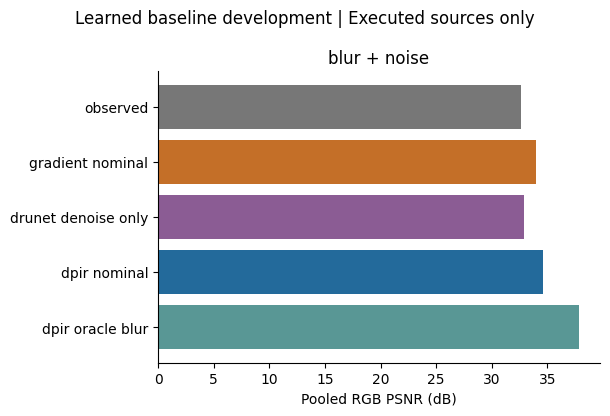

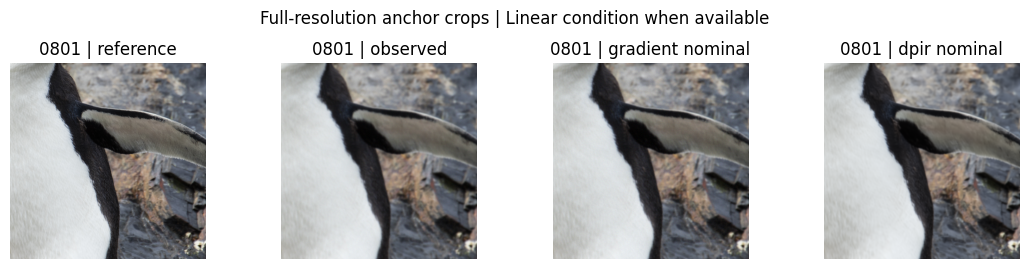

In [7]:
display(result['summary'].round(6))
display(result['compute'].groupby('variant', as_index=False).agg(
    runs=('elapsed_seconds','size'), total_seconds=('elapsed_seconds','sum'),
    mean_seconds=('elapsed_seconds','mean'), denoiser_calls=('denoiser_calls','sum')).round(3))
display(result['figures'][0])
display(result['figures'][2])


### 8. Detail selection and iteration diagnostics
Compare operator spread with the fixed-operator image-transformation score and inexpensive residual/gradient controls. Random risk is its exact expectation. Neither a low residual nor a visually pleasing image establishes fidelity to the clean reference.

,scenario,region,score,detail_mse,rgb_mse,bad_detail_rate_005
0,blur_noise,all,image_gradient,0.000056,0.000116,0.0
1,blur_noise,all,image_transform_spread_detail,0.000035,0.000083,0.0
2,blur_noise,all,measurement_residual,0.000154,0.000405,0.0
3,blur_noise,all,operator_spread_detail,0.000030,0.000077,0.0
4,blur_noise,all,operator_spread_rgb,0.000038,0.000087,0.0
5,blur_noise,all,oracle_detail_error,0.000021,0.000068,0.0
6,blur_noise,all,random_expected,0.000135,0.000348,0.0
7,blur_noise,textured_quartile,image_gradient,0.000240,0.000588,0.0
8,blur_noise,textured_quartile,image_transform_spread_detail,0.000226,0.000558,0.0
9,blur_noise,textured_quartile,measurement_residual,0.000386,0.001015,0.0


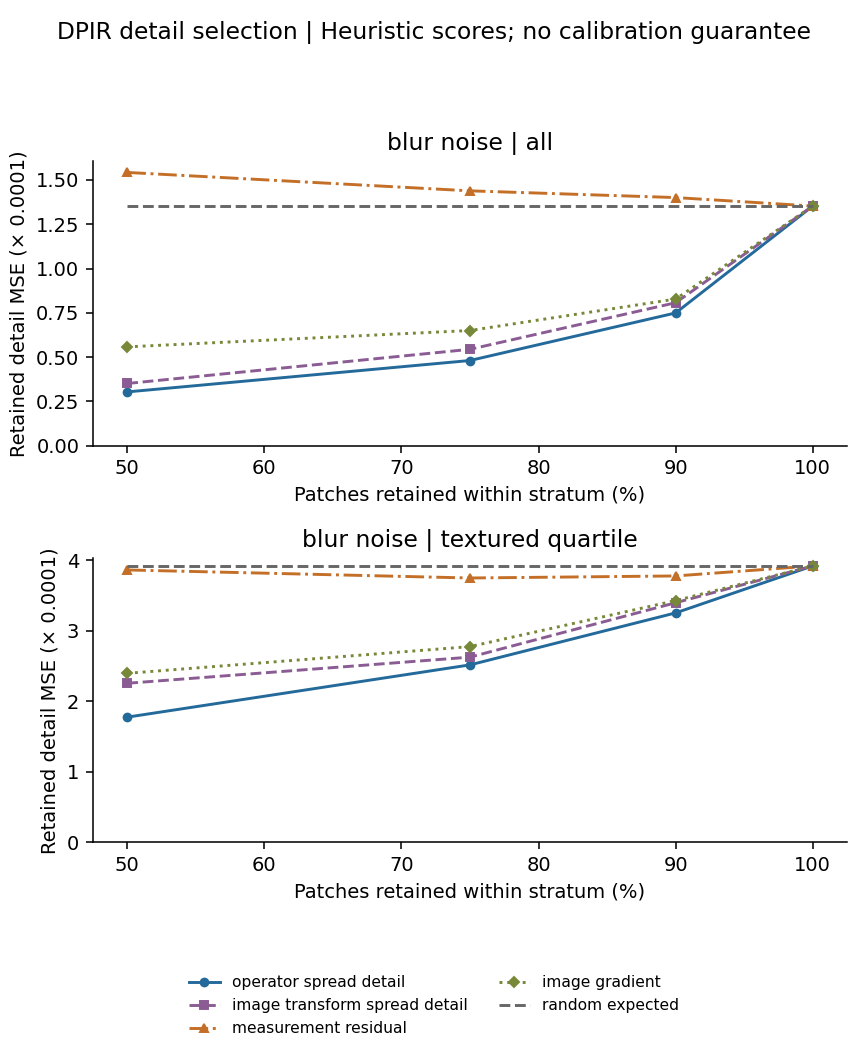

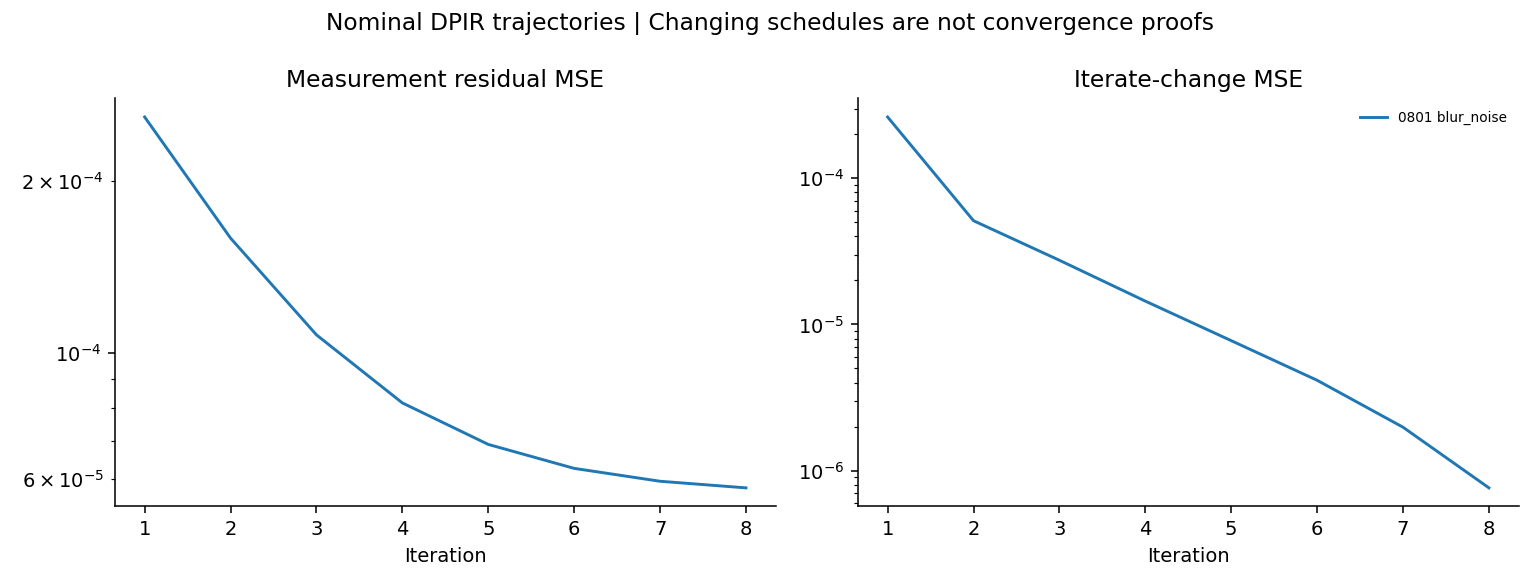

In [8]:
half = result['curves'].query('coverage == 0.5').groupby(['scenario','region','score'], as_index=False).agg(
    detail_mse=('detail_mse','mean'), rgb_mse=('rgb_mse','mean'),
    bad_detail_rate_005=('bad_detail_rate_0.05','mean'))
display(half.round(7))
display(result['figures'][1])
display(result['figures'][3])


### 9. Computed readout and next decision
Read these as bounded development results. A negative score comparison is retained. No global novelty or scoping-review verdict follows from this experiment.

In [9]:
summary = result['summary']
for scenario in CONFIG['scenarios']:
    values = summary[summary.scenario == scenario].set_index('model').mean_mse
    for model in ['gradient_nominal','drunet_denoise_only','dpir_nominal','dpir_oracle_blur']:
        print(f'{scenario} | {model}: pooled gain over input {10*np.log10(values.observed/values[model]):+.3f} dB')
for (scenario, region), frame in half.groupby(['scenario','region']):
    values = frame.set_index('score').detail_mse
    controls = values[['image_transform_spread_detail','measurement_residual','image_gradient']]
    reduction = 100 * (1 - values.operator_spread_detail / controls.min())
    print(f'{scenario} | {region}: operator detail spread vs lowest-error included control ({controls.idxmin()}), at 50% coverage: {reduction:+.2f}% detail-MSE reduction')
print('Completed observations:', result['completed_observations'])
print('Configured sources:', CONFIG['source_ids'], '| conditions:', CONFIG['scenarios'])
print('Eight-observation development plan complete:', result['completed_observations'] == 8)
print('No independent-test, statistical-significance, calibration or novelty claim.')
print('Results saved:', OUTPUT_DIR)


blur_noise | gradient_nominal: pooled gain over input +1.371 dB
blur_noise | drunet_denoise_only: pooled gain over input +0.357 dB
blur_noise | dpir_nominal: pooled gain over input +1.998 dB
blur_noise | dpir_oracle_blur: pooled gain over input +5.254 dB
blur_noise | all: operator detail spread vs lowest-error included control (image_transform_spread_detail), at 50% coverage: +13.58% detail-MSE reduction
blur_noise | textured_quartile: operator detail spread vs lowest-error included control (image_transform_spread_detail), at 50% coverage: +21.29% detail-MSE reduction
Completed observations: 1
Configured sources: ['0801'] | conditions: ['blur_noise']
Eight-observation development plan complete: False
No independent-test, statistical-significance, calibration or novelty claim.
Results saved: /workspace/scratch/7ff69f9960d0/reliable-reconstruction-under-mismatch/experiments/learned_02/outputs/canary_20260917


## Takeaways and reproduction
The decision is to establish a trustworthy learned-baseline comparison before designing a custom method. Run the full eight-observation configuration before drawing even a four-source development conclusion. A promising score must next survive stronger image-only uncertainty comparators, independent learned families, compute checks and source-disjoint calibration/testing. Repeated tuning of these four exposed sources cannot supply independent confirmation.

The scoping review remains a separate route. Its viability depends on added value over existing reviews and a completed formal method; an individual experimental score cannot settle it.

- [Official DPIR code at the inspected commit](https://github.com/cszn/DPIR/tree/15bca3fcc1f3cc51a1f99ccf027691e278c19354)
- [DPIR paper, inspected v2](https://arxiv.org/html/2008.13751v2)
- [Official checkpoint downloader](https://github.com/cszn/DPIR/blob/15bca3fcc1f3cc51a1f99ccf027691e278c19354/main_download_pretrained_models.py)
- [Official DIV2K](https://data.vision.ee.ethz.ch/cvl/DIV2K/)

Generated from `experiments/learned_02/learned.py` and the existing Baseline 01 helper. Their hashes are in notebook metadata and run provenance. The recorded checkpoint SHA-256 is our observed digest, not a publisher-signed checksum. Local in-process execution does not validate Colab/Drive or GPU behaviour; notebook metadata records that distinction. Raw source images and pretrained weights are not bundled into the notebook.
